# Phase 2: Exploratory Data Analysis (EDA)

### Step 1: Import Libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
# warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

### Step 2: Load Cleaned Data

In [11]:
df = pd.read_csv("../data/processed/cleaned_tickets.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (5022, 58)


,Id,started,ended,issue_num,issue_proj,issue_reporter,issue_assignee,issue_contr_count,issue_type,issue_priority,...,wf_cancelled,wfe_cancelled,wf_under_review,wfe_under_review,wf_approved,wfe_approved,wf_pending_deployment,wfe_pending_deployment,wf_total_time,processing_steps
0,11887,2016-01-06 08:23:43+00:00,2016-01-06 08:56:55+00:00,186,d1z0,4olg,NaN,1.0,Ticket,Medium,...,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,1992.0,2.0
1,11890,2016-01-11 10:06:19+00:00,2016-01-12 12:30:23+00:00,190,d1z0,4olg,NaN,1.0,Ticket,Medium,...,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,95044.0,2.0
2,11904,2016-01-21 07:28:20+00:00,2016-01-26 08:21:47+00:00,198,d1z0,4ohk,4ohk,1.0,Ticket,Medium,...,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,435207.0,2.0
3,11907,2016-01-26 07:44:54+00:00,2016-01-26 07:45:48+00:00,209,d1z0,4olg,NaN,1.0,Vacation,Medium,...,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,54.0,2.0
4,11912,2016-02-01 13:45:47+00:00,2016-02-07 06:21:42+00:00,217,d1z0,4ohk,4ohk,1.0,Story,Medium,...,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,491755.0,2.0


### Step 3: Statistical Summary

In [12]:
df.describe()

,Id,issue_num,issue_contr_count,issue_comments_count,wf_in_review,wfe_in_review,wf_deployment,wfe_deployment,wf_resolved,wfe_resolved,...,wf_cancelled,wfe_cancelled,wf_under_review,wfe_under_review,wf_approved,wfe_approved,wf_pending_deployment,wfe_pending_deployment,wf_total_time,processing_steps
count,5.022000e+03,5022.000000,5022.000000,5022.000000,0.0,5022.0,3.000000e+00,5022.000000,6.970000e+02,5022.000000,...,0.0,5022.0,0.0,5022.0,0.0,5022.0,0.0,5022.0,5.022000e+03,5022.000000
mean,2.623295e+07,670.806053,1.023098,4.851454,NaN,0.0,1.695891e+06,0.000597,1.585755e+06,0.152728,...,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,2.286680e+07,1.747511
std,2.201507e+07,954.693396,0.160487,8.687282,NaN,0.0,7.327890e+05,0.024436,7.870518e+06,0.408985,...,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,2.909792e+07,1.424027
min,1.061600e+04,1.000000,1.000000,0.000000,NaN,0.0,8.832830e+05,0.000000,1.000000e+00,0.000000,...,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,3.000000e+00,1.000000
25%,1.220525e+04,85.000000,1.000000,0.000000,NaN,0.0,1.390599e+06,0.000000,1.100000e+01,0.000000,...,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,1.184935e+06,1.000000
50%,4.145450e+07,186.000000,1.000000,2.000000,NaN,0.0,1.897915e+06,0.000000,9.300000e+01,0.000000,...,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,1.097214e+07,1.000000
75%,4.569375e+07,463.750000,1.000000,6.000000,NaN,0.0,2.102196e+06,0.000000,3.690000e+02,0.000000,...,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,4.208012e+07,2.000000
max,4.780600e+07,3448.000000,3.000000,150.000000,NaN,0.0,2.306476e+06,1.000000,4.570027e+07,5.000000,...,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,3.506091e+08,20.000000


### Step 4: Univariate Analysis

In [13]:
categorical_cols = df.select_dtypes(include=['object']).columns[:5]
for col in categorical_cols:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts().head())


started: 5020 unique values
started
2015-12-13 08:19:08+00:00    2
2016-01-17 11:46:56+00:00    2
2016-01-06 08:23:43+00:00    1
2016-01-11 10:06:19+00:00    1
2016-01-21 07:28:20+00:00    1
Name: count, dtype: int64

ended: 4336 unique values
ended
2016-12-02 14:53:50+00:00    12
2017-09-17 11:43:06+00:00    11
2016-12-02 14:53:49+00:00    11
2017-09-17 11:43:21+00:00    11
2017-12-21 09:14:07+00:00    10
Name: count, dtype: int64

issue_proj: 175 unique values
issue_proj
t96     543
d1z0    286
d10t    257
dzc0    257
dzc8    254
Name: count, dtype: int64

issue_reporter: 323 unique values
issue_reporter
4opp    257
4gis    192
4hhr    165
4hlg    156
4hsq    139
Name: count, dtype: int64

issue_assignee: 85 unique values
issue_assignee
4pro    95
4osr    85
4gsg    77
4prh    63
4hpp    61
Name: count, dtype: int64


### Step 5: Bivariate Analysis

In [14]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()
print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
                                     Id  issue_num  issue_contr_count  \
Id                             1.000000   0.316720          -0.152777   
issue_num                      0.316720   1.000000          -0.029339   
issue_contr_count             -0.152777  -0.029339           1.000000   
issue_comments_count           0.264104   0.240205           0.011461   
wf_in_review                        NaN        NaN                NaN   
wfe_in_review                       NaN        NaN                NaN   
wf_deployment                  0.099278  -0.971263                NaN   
wfe_deployment                -0.029109   0.006203          -0.003519   
wf_resolved                    0.105806  -0.125623          -0.032261   
wfe_resolved                   0.081975   0.178708           0.073684   
wf_open                        0.419060   0.047372          -0.079629   
wfe_open                      -0.101899   0.015849           0.463803   
wf_monitoring                 -

### Step 6: Data Visualization

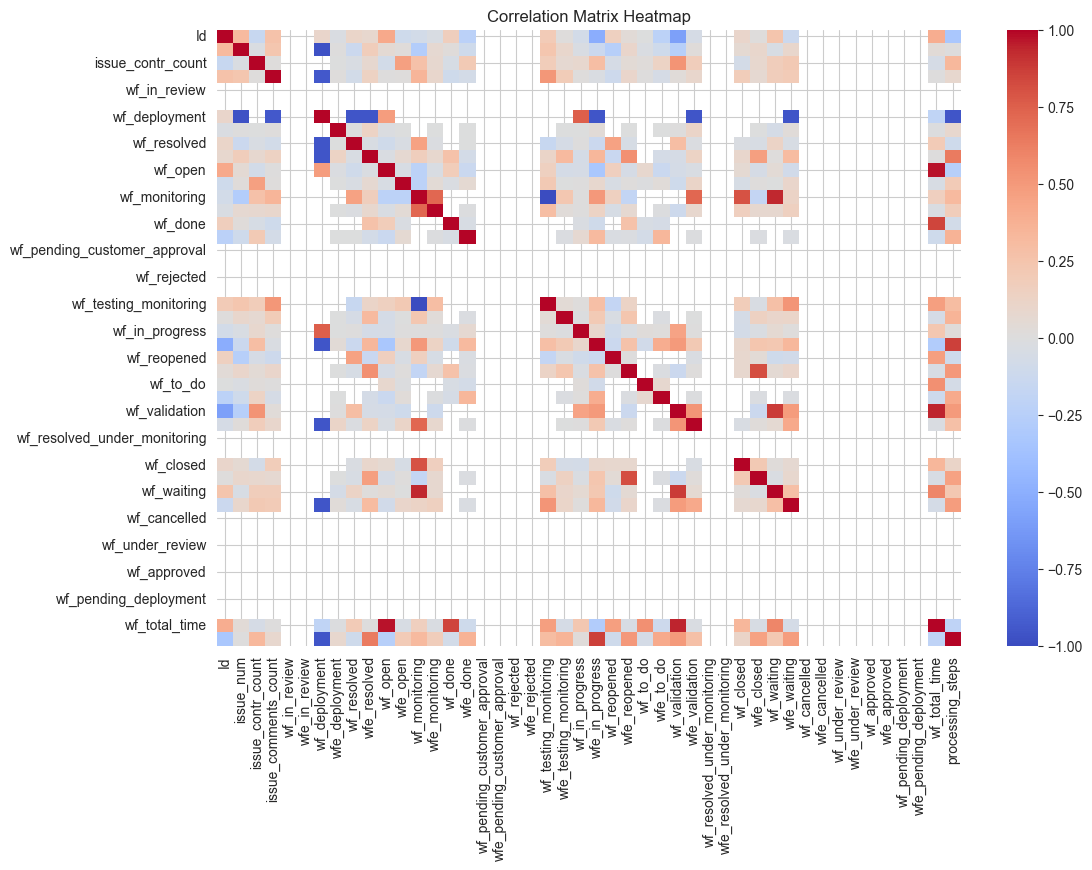

In [7]:
# Heatmap of correlations
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

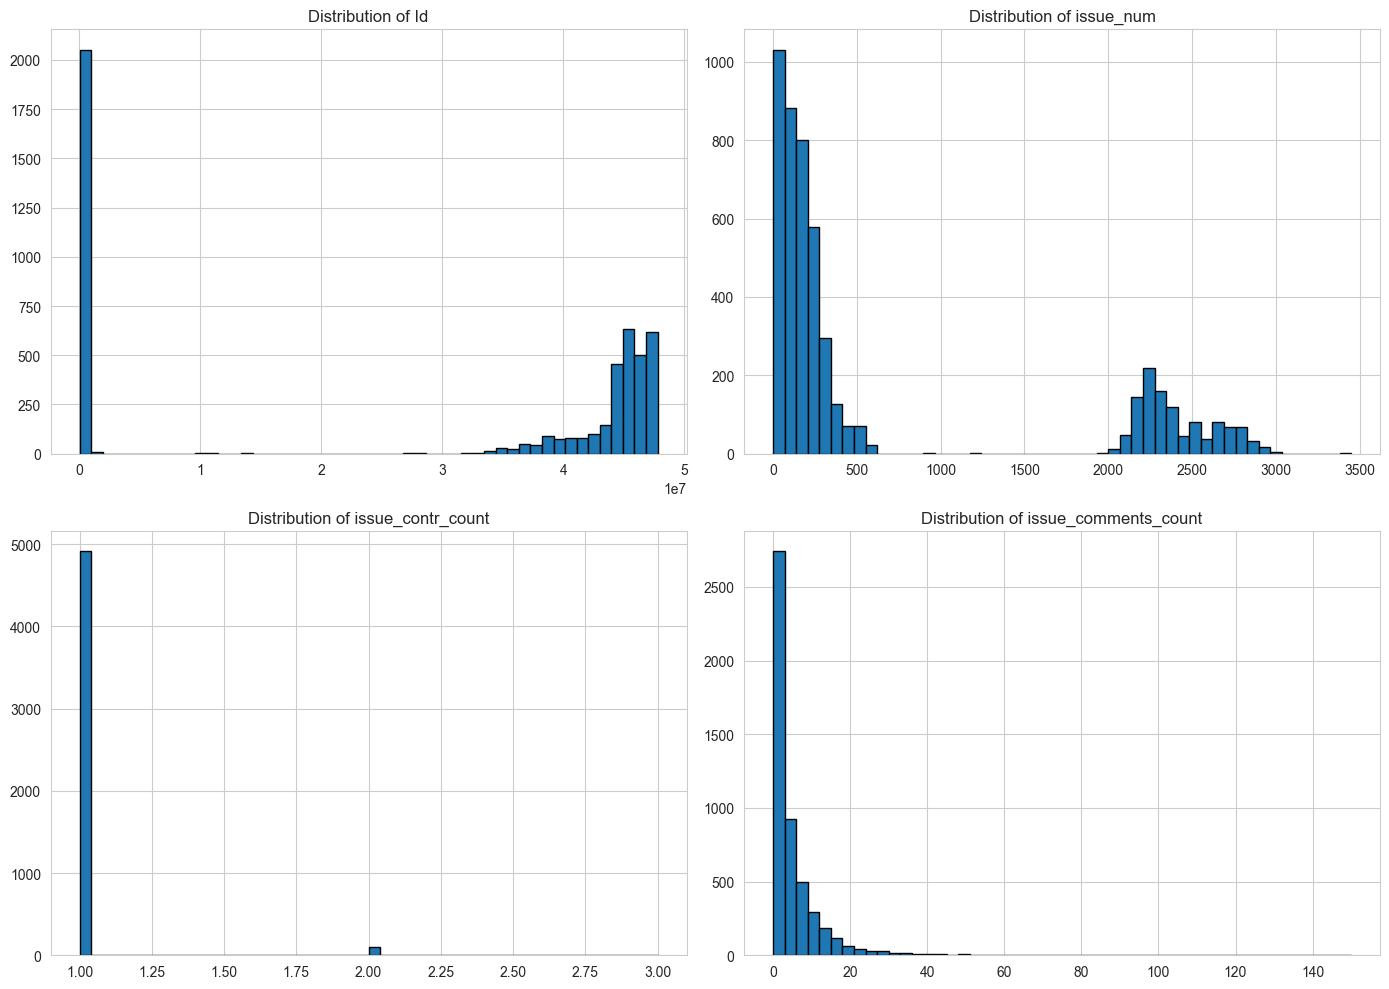

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
numeric_cols_sample = numeric_cols[:4]

for idx, col in enumerate(numeric_cols_sample):
    ax = axes[idx // 2, idx % 2]
    df[col].hist(bins=50, ax=ax, edgecolor='black')
    ax.set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

### Step 7: Key Insights & Findings

In [16]:
# Generate comprehensive insights report
print("="*70)
print("EXPLORATORY DATA ANALYSIS - KEY INSIGHTS & FINDINGS")
print("="*70)

print("\n1. DATASET OVERVIEW")
print("-" * 70)
print(f"   • Total Records: {len(df):,}")
print(f"   • Total Features: {df.shape[1]}")
print(f"   • Numeric Features: {df.select_dtypes(include=[np.number]).shape[1]}")
print(f"   • Categorical Features: {df.select_dtypes(include=['object']).shape[1]}")
print(f"   • Missing Values: {df.isnull().sum().sum()}")

print("\n2. DATA DISTRIBUTION")
print("-" * 70)
for col in numeric_cols[:5]:
    print(f"   • {col}:")
    print(f"     - Mean: {df[col].mean():.2f}")
    print(f"     - Median: {df[col].median():.2f}")
    print(f"     - Std Dev: {df[col].std():.2f}")
    print(f"     - Min: {df[col].min():.2f}, Max: {df[col].max():.2f}")

print("\n3. CORRELATION INSIGHTS")
print("-" * 70)
# Top correlations
corr_values = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_values.append((
            correlation_matrix.columns[i],
            correlation_matrix.columns[j],
            correlation_matrix.iloc[i, j]
        ))

corr_values.sort(key=lambda x: abs(x[2]), reverse=True)
print("   Top 5 Strongest Correlations:")
for idx, (col1, col2, corr) in enumerate(corr_values[:5], 1):
    print(f"   {idx}. {col1} ↔ {col2}: {corr:.4f}")

print("\n4. CATEGORICAL ANALYSIS")
print("-" * 70)
for col in categorical_cols[:3]:
    print(f"   • {col}:")
    print(f"     - Unique Values: {df[col].nunique()}")
    top_val = df[col].value_counts().index[0]
    top_count = df[col].value_counts().values[0]
    print(f"     - Most Common: {top_val} ({top_count} occurrences)")

print("\n5. DATA QUALITY ASSESSMENT")
print("-" * 70)
print(f"   • Completeness: {(1 - df.isnull().sum().sum()/(df.shape[0]*df.shape[1]))*100:.2f}%")
print(f"   • Duplicate Records: {df.duplicated().sum()}")
print(f"   • Data Types: {df.dtypes.value_counts().to_dict()}")

print("\n6. STATISTICAL SUMMARY")
print("-" * 70)
numeric_summary = df.describe()
for col in numeric_cols[:3]:
    skewness = df[col].skew()
    kurtosis = df[col].kurtosis()
    print(f"   • {col}:")
    print(f"     - Skewness: {skewness:.4f} (Distribution shape)")
    print(f"     - Kurtosis: {kurtosis:.4f} (Tail behavior)")

print("\n" + "="*70)
print("ANALYSIS COMPLETE - Ready for Model Building")
print("="*70)

EXPLORATORY DATA ANALYSIS - KEY INSIGHTS & FINDINGS

1. DATASET OVERVIEW
----------------------------------------------------------------------
   • Total Records: 5,022
   • Total Features: 58
   • Numeric Features: 46
   • Categorical Features: 12
   • Missing Values: 96397

2. DATA DISTRIBUTION
----------------------------------------------------------------------
   • Id:
     - Mean: 26232945.28
     - Median: 41454500.00
     - Std Dev: 22015074.39
     - Min: 10616.00, Max: 47806000.00
   • issue_num:
     - Mean: 670.81
     - Median: 186.00
     - Std Dev: 954.69
     - Min: 1.00, Max: 3448.00
   • issue_contr_count:
     - Mean: 1.02
     - Median: 1.00
     - Std Dev: 0.16
     - Min: 1.00, Max: 3.00
   • issue_comments_count:
     - Mean: 4.85
     - Median: 2.00
     - Std Dev: 8.69
     - Min: 0.00, Max: 150.00
   • wf_in_review:
     - Mean: nan
     - Median: nan
     - Std Dev: nan
     - Min: nan, Max: nan

3. CORRELATION INSIGHTS
-------------------------------------